# **TUGAS ANALISIS DATA TIDAK TERSTUKTUR PEKAN 7**

**Nama** : Theresa Ray Ratri  
**NPM**  : 2306249703  
**Kelas**: A

# **Import Library dan Data**

In [ ]:
# import library yang digunakan
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_squared_error, mean_absolute_error

import statsmodels.api as sm

import itertools
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# load data
df = pd.read_csv('f1_final.csv')
df['Time'] = pd.to_datetime(df['Time'])
df.set_index('Time', inplace=True)

# pilih variabel
y = df['Formula1']

X = df[['MaxVerstappen','LewisHamilton',
        'CharlesLeclerc','CarlosSainz',
        'FernandoAlonso','Race_dummy']]

# **Analisis Deskriptif**

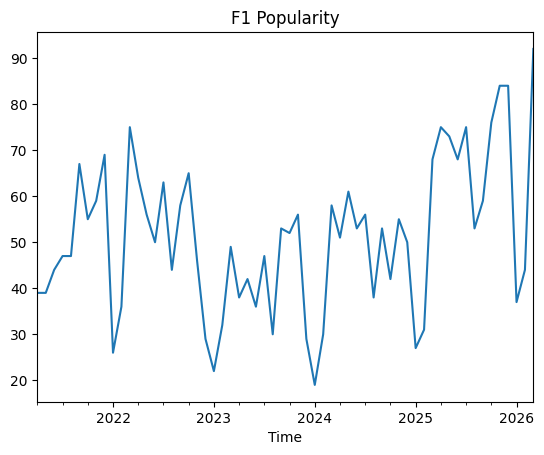

In [ ]:
y.plot(title="F1 Popularity")
plt.show()

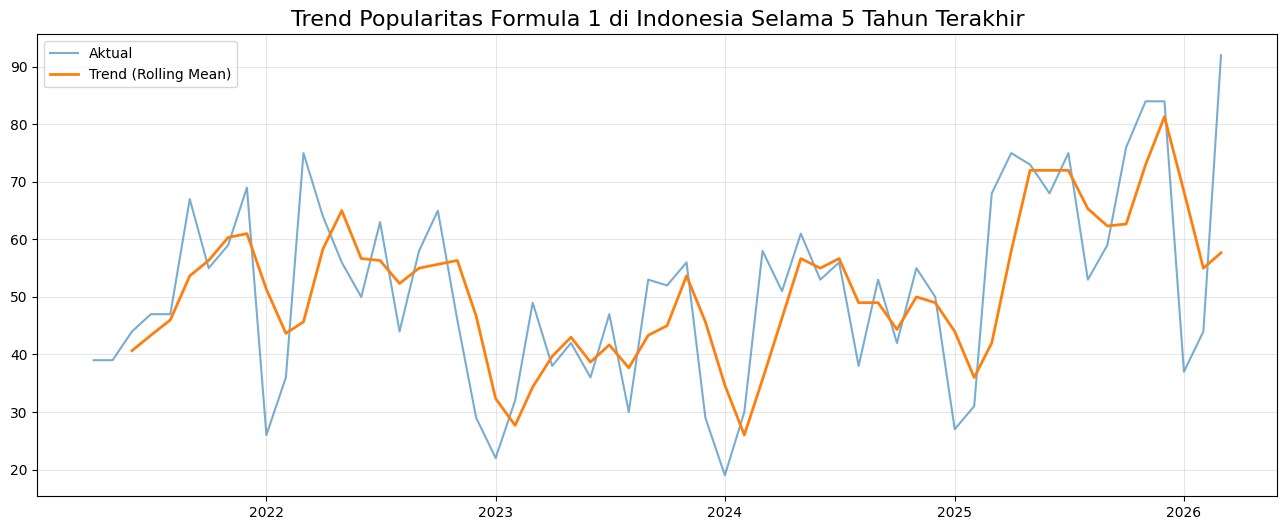

In [ ]:
rolling = y.rolling(3).mean()

plt.figure(figsize=(16,6))
plt.plot(y, label='Aktual', alpha=0.6)
plt.plot(rolling, label='Trend (Rolling Mean)', linewidth=2)

plt.title("Trend Popularitas Formula 1 di Indonesia Selama 5 Tahun Terakhir", fontsize=16)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

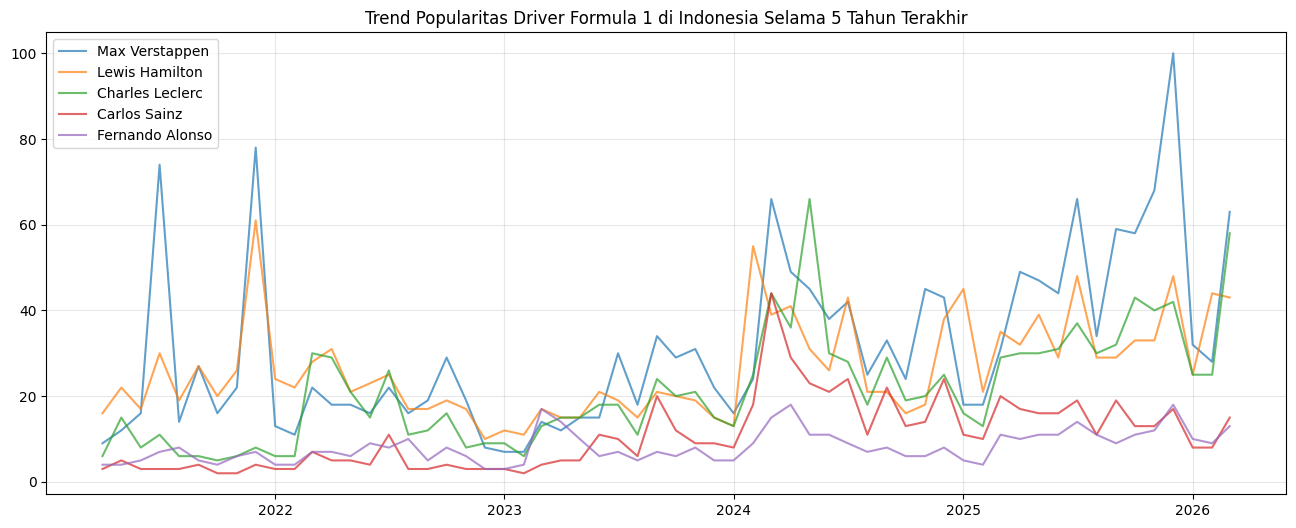

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(df['MaxVerstappen'], label='Max Verstappen', alpha=0.7)
plt.plot(df['LewisHamilton'], label='Lewis Hamilton', alpha=0.7)
plt.plot(df['CharlesLeclerc'], label='Charles Leclerc', alpha=0.7)
plt.plot(df['CarlosSainz'], label='Carlos Sainz', alpha=0.7)
plt.plot(df['FernandoAlonso'], label='Fernando Alonso', alpha=0.7)
plt.legend()
plt.title("Trend Popularitas Driver Formula 1 di Indonesia Selama 5 Tahun Terakhir")
plt.grid(alpha=0.3)

plt.show()

# **Modelling**

**Decomposition Plot**

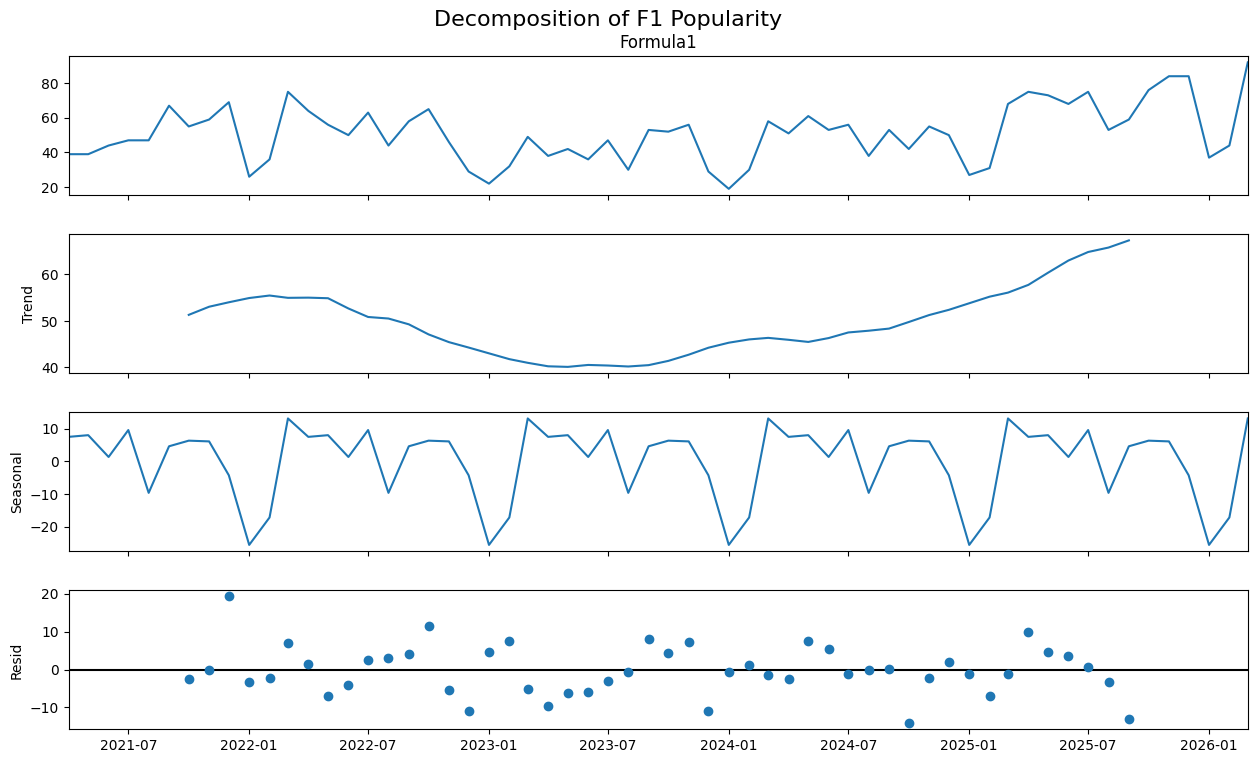

In [ ]:
decomposition = seasonal_decompose(y, model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(14,8)
plt.suptitle("Decomposition of F1 Popularity", fontsize=16)
plt.show()

**Uji Stasioneritas**

In [ ]:
# ADF level
from statsmodels.tsa.stattools import adfuller

adf_level = adfuller(y)

print("ADF LEVEL")
print("ADF Statistic:", adf_level[0])
print("p-value:", adf_level[1])

# Differencing
y_diff = y.diff().diff(12).dropna()

adf_diff = adfuller(y_diff)

print("\nADF DIFFERENCING")
print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

ADF LEVEL
ADF Statistic: 1.079202000778413
p-value: 0.9950351524546256

ADF DIFFERENCING
ADF Statistic: -5.5183788771166
p-value: 1.9021169510141342e-06


**Pemodelan SARIMA**

In [ ]:
# split data
train_size = int(len(y)*0.8)


y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.1 MB/s eta 0:00:00


In [ ]:
from pmdarima import auto_arima

model = auto_arima(y_train,
                   seasonal=True,
                   m=12,
                   trace=True,
                   error_action='ignore',
                   suppress_warnings=True,
                   stepwise=True,
                   stationary=False)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=377.689, Time=0.94 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=389.591, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=377.870, Time=1.53 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=380.378, Time=0.76 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=511.601, Time=0.03 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=385.762, Time=1.34 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=378.081, Time=0.30 sec
 ARIMA(2,0,2)(2,0,1)[12] intercept   : AIC=378.349, Time=0.75 sec
 ARIMA(2,0,2)(1,0,2)[12] intercept   : AIC=inf, Time=0.69 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=392.155, Time=0.09 sec
 ARIMA(2,0,2)(0,0,2)[12] intercept   : AIC=386.520, Time=0.60 sec
 ARIMA(2,0,2)(2,0,0)[12] intercept   : AIC=377.518, Time=0.64 sec
 ARIMA(1,0,2)(2,0,0)[12] intercept   : AIC=376.800, Time=0.52 sec
 ARIMA(1,0,2)(1,0,0)[12] intercept   : AIC=376.922, Time=0.22 sec
 ARIMA(1,0,2)(2,0,1)[12] intercept   

In [ ]:
order = auto_model.order
seasonal_order = auto_model.seasonal_order

print("Order:", order)
print("Seasonal Order:", seasonal_order)

Order: (1, 0, 2)
Seasonal Order: (2, 0, 0, 12)


In [ ]:
model_sarima = SARIMAX(y_train,
                      order=order,
                      seasonal_order=seasonal_order,
                      trend='c')

result_sarima = model_sarima.fit(disp=False)

print(result_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                            Formula1   No. Observations:                   48
Model:             SARIMAX(1, 0, 2)x(2, 0, [], 12)   Log Likelihood                -181.400
Date:                             Fri, 03 Apr 2026   AIC                            376.800
Time:                                     20:32:33   BIC                            389.899
Sample:                                 04-01-2021   HQIC                           381.750
                                      - 03-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     31.8121     15.380      2.068      0.039       1.667      61.957
ar.L1         -0.9626      

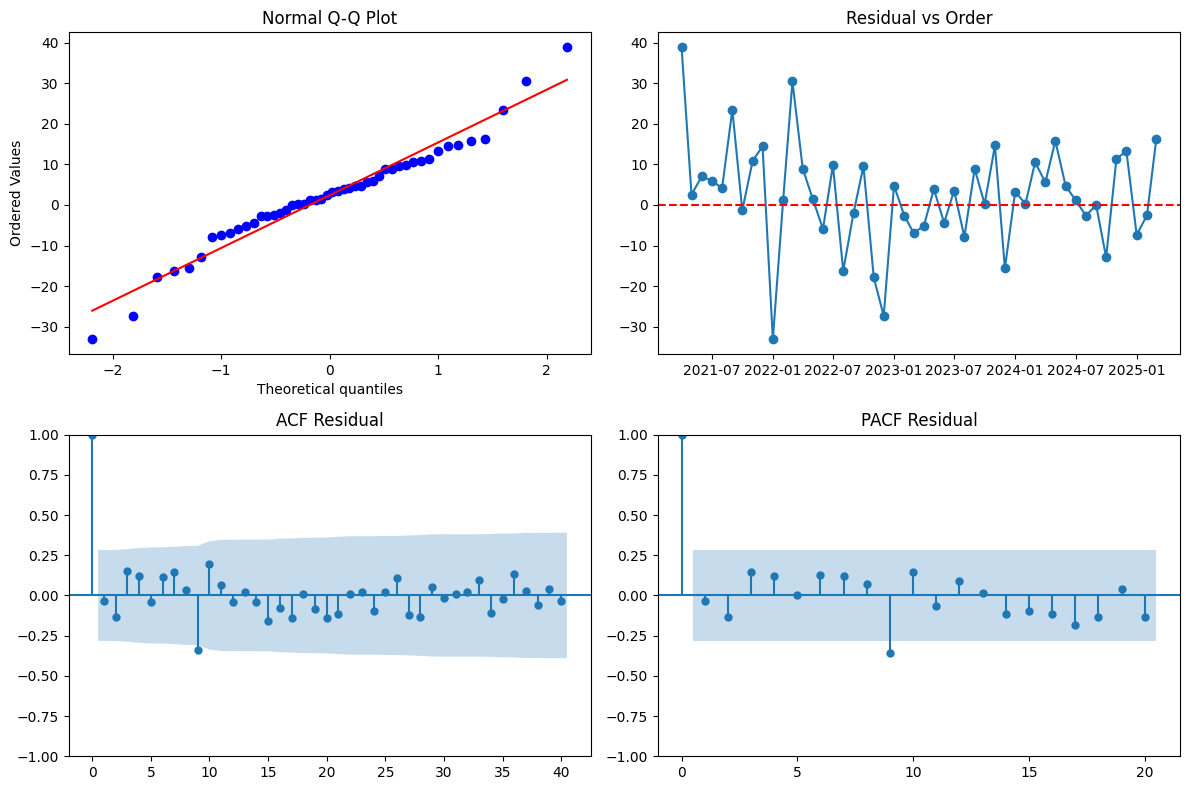

In [ ]:
# Ambil residual dari model
residuals = result_sarima.resid

# Buat plot 2x2
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# 1. QQ Plot (cek normalitas)
stats.probplot(residuals, dist="norm", plot=ax[0, 0])
ax[0, 0].set_title("Normal Q-Q Plot")

# 2. Residual vs Order (cek pola)
ax[0, 1].plot(residuals, marker='o')
ax[0, 1].axhline(y=0, color='red', linestyle='--')
ax[0, 1].set_title("Residual vs Order")

# 3. ACF (cek autokorelasi)
plot_acf(residuals, ax=ax[1, 0], lags=40)
ax[1, 0].set_title("ACF Residual")

# 4. PACF
max_lags = min(20, len(residuals)//2 - 1)

plot_pacf(residuals, ax=ax[1,1], lags=max_lags, method='ywm')
ax[1, 1].set_title("PACF Residual")

plt.tight_layout()
plt.show()

**Pemodelan SARIMAX**

In [ ]:
model_sarimax = SARIMAX(y_train,
                      exog=X_train,
                      order=order,
                      seasonal_order=seasonal_order,
                      trend='c')

result_sarimax = model_sarimax.fit(disp=False)

print(result_sarimax.summary())

                                      SARIMAX Results                                      
Dep. Variable:                            Formula1   No. Observations:                   48
Model:             SARIMAX(1, 0, 2)x(2, 0, [], 12)   Log Likelihood                -164.481
Date:                             Fri, 03 Apr 2026   AIC                            354.962
Time:                                     20:34:53   BIC                            379.288
Sample:                                 04-01-2021   HQIC                           364.155
                                      - 03-01-2025                                         
Covariance Type:                               opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept          2.7107      2.819      0.961      0.336      -2.815       8.237
MaxVerstappen  

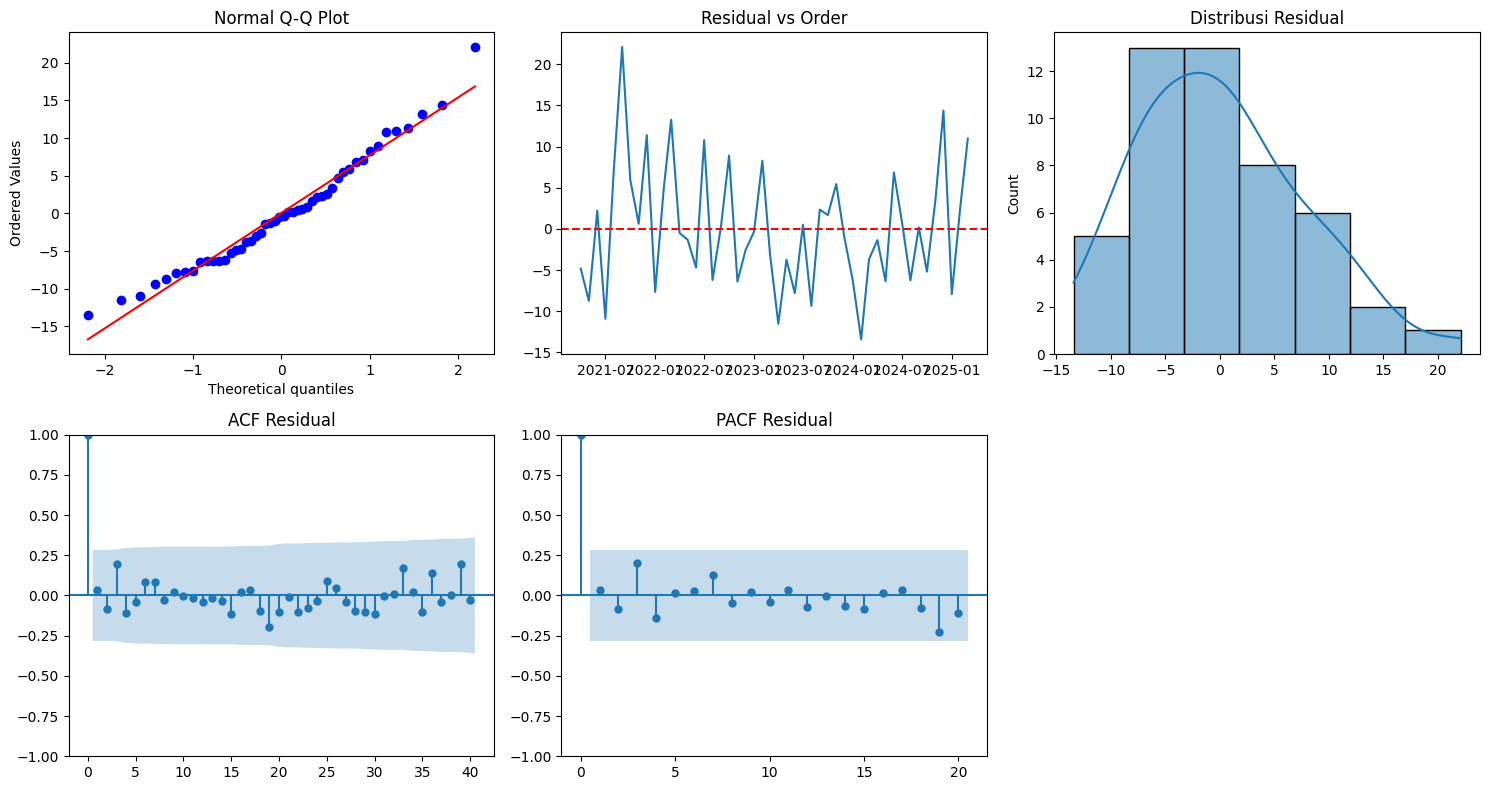

In [ ]:
residuals = result_sarimax.resid

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# 1. QQ Plot (normalitas)
stats.probplot(residuals, dist="norm", plot=ax[0, 0])
ax[0, 0].set_title("Normal Q-Q Plot")

# 2. Residual vs waktu
ax[0, 1].plot(residuals)
ax[0, 1].axhline(y=0, color='r', linestyle='--')
ax[0, 1].set_title("Residual vs Order")

# 3. Histogram + KDE (Distribusi)
sns.histplot(residuals, kde=True, ax=ax[0, 2])
ax[0, 2].set_title("Distribusi Residual")

# 4. ACF
plot_acf(residuals, ax=ax[1, 0], lags=40)
ax[1, 0].set_title("ACF Residual")

# 5. PACF
plot_pacf(residuals, ax=ax[1, 1], lags=20)
ax[1, 1].set_title("PACF Residual")

# 6. Kosongin subplot terakhir biar rapi
ax[1, 2].axis('off')

plt.tight_layout()
plt.show()

# **Evaluasi Model**

In [ ]:
# forecast
pred_sarima = result_sarima.forecast(steps=len(y_test))
pred_sarimax = result_sarimax.forecast(steps=len(y_test), exog=X_test)

In [ ]:
# evaluasi
rmse_sarima = np.sqrt(mean_squared_error(y_test, pred_sarima))
mae_sarima = mean_absolute_error(y_test, pred_sarima)


rmse_sarimax = np.sqrt(mean_squared_error(y_test, pred_sarimax))
mae_sarimax = mean_absolute_error(y_test, pred_sarimax)


print("SARIMA RMSE:", rmse_sarima)
print("SARIMA MAE:", mae_sarima)


print("SARIMAX RMSE:", rmse_sarimax)
print("SARIMAX MAE:", mae_sarimax)

SARIMA RMSE: 21.891159884461796
SARIMA MAE: 19.323334746444498
SARIMAX RMSE: 8.640077488382389
SARIMAX MAE: 7.322234112348023


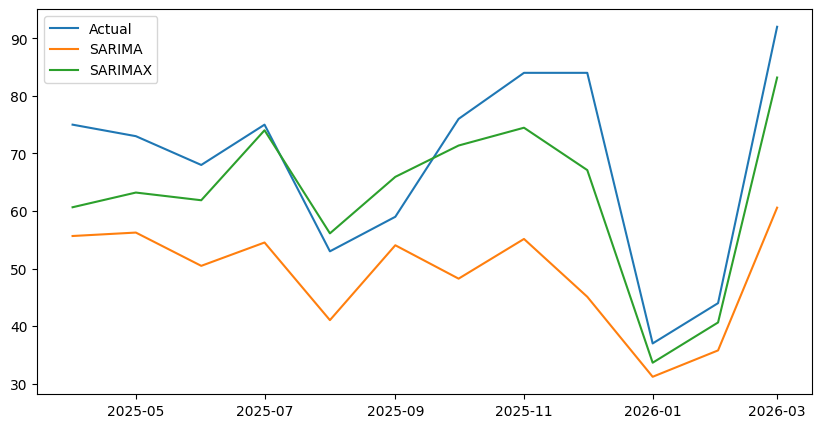

In [ ]:
# plot hasil
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual')
plt.plot(pred_sarima, label='SARIMA')
plt.plot(pred_sarimax, label='SARIMAX')
plt.legend()
plt.show()


# **Forecasting**

In [ ]:
# jumlah periode ke depan (12 bulan)
n_steps = 12

# buat future exog (pakai nilai terakhir sebagai asumsi)
last_X = X.iloc[-1]

future_X = pd.DataFrame([last_X]*n_steps)

# forecast
forecast_future = result_sarimax.forecast(steps=n_steps, exog=future_X)

In [ ]:
future_dates = pd.date_range(start=y.index[-1],
                             periods=n_steps+1,
                             freq='M')[1:]

forecast_future.index = future_dates

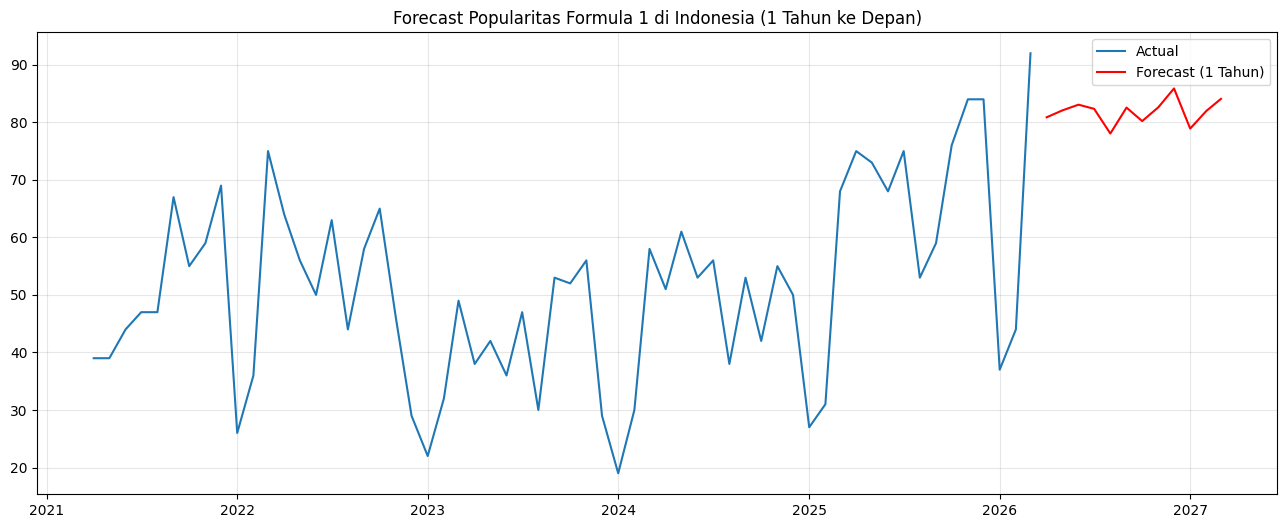

In [ ]:
plt.figure(figsize=(16,6))

# data asli
plt.plot(y, label='Actual')

# forecast masa depan
plt.plot(forecast_future, label='Forecast (1 Tahun)', color='red')

plt.title("Forecast Popularitas Formula 1 di Indonesia (1 Tahun ke Depan)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

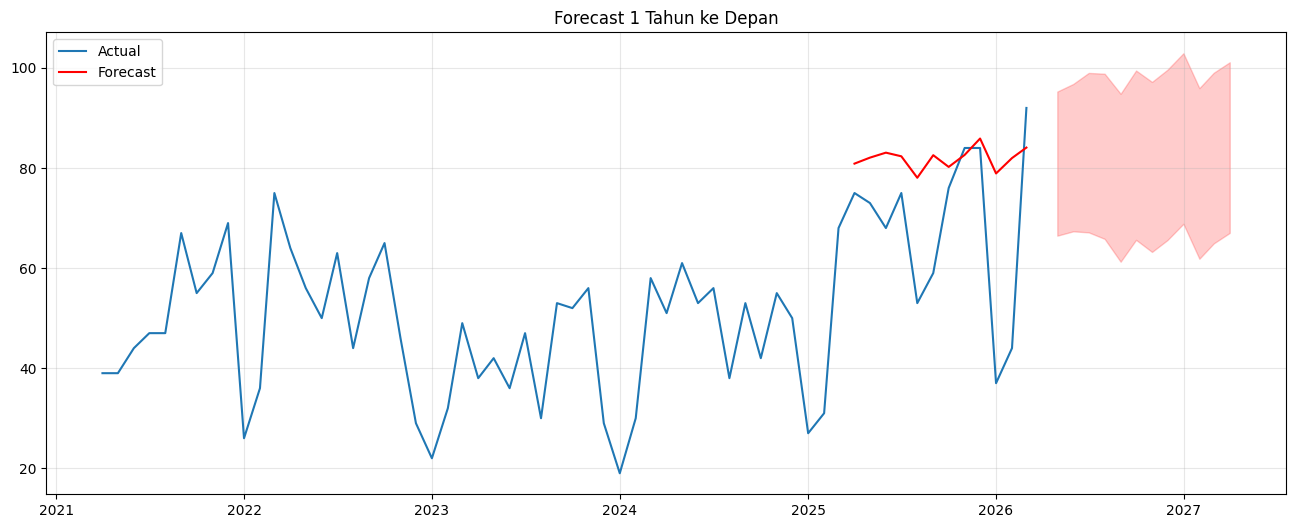

In [ ]:
forecast = result_sarimax.get_forecast(steps=n_steps, exog=future_X)
conf_int = forecast.conf_int()

plt.figure(figsize=(16,6))

plt.plot(y, label='Actual')
plt.plot(forecast.predicted_mean, label='Forecast', color='red')

plt.fill_between(future_dates,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='red', alpha=0.2)

plt.title("Forecast 1 Tahun ke Depan")
plt.legend()
plt.grid(alpha=0.3)

plt.show()